In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import STL

In [77]:
df_fish = pd.read_csv("./Wait_confirm_dataset/fish_life_quality.csv")

In [201]:
df

,Date,Time,PH,TEMP,DO,TURBIDITY,tempC,label
0,01-02-2022,08:00:00,7.70000,24.35000,1.90000,21.30000,27,0
1,01-02-2022,08:20:00,7.60000,24.30000,0.80000,31.00000,30,0
2,01-02-2022,08:40:00,8.50000,24.28000,2.60000,27.40000,33,0
3,01-02-2022,09:00:00,7.50000,24.25000,2.90000,21.90000,37,0
4,01-02-2022,09:20:00,7.40000,24.10000,1.30000,22.70000,37,0
...,...,...,...,...,...,...,...,...
74753,20-01-2023,13:40:00,5.43202,23.25975,14.54672,17.21850,25,1
74754,20-01-2023,14:00:00,6.15657,20.21007,23.46253,16.45933,25,1
74755,20-01-2023,14:20:00,5.63154,20.35273,16.66173,18.19536,27,1
74756,20-01-2023,14:40:00,6.75828,15.56445,6.44569,18.46460,25,1


In [99]:
df_fish = df[["PH","TEMP","DO","TURBIDITY","label"]]

In [64]:
list(range(10))[::3]

[0, 3, 6, 9]

<Axes: ylabel='TEMP'>

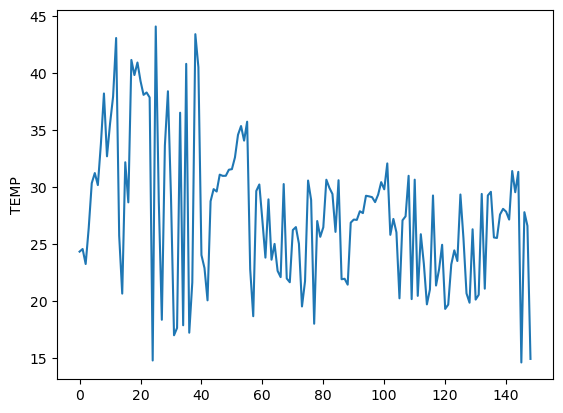

In [76]:
n = 3*24*7
sns.lineplot(data=(df[::n]),x=range(len(df[::n])),y="TEMP")

<Axes: ylabel='PH'>

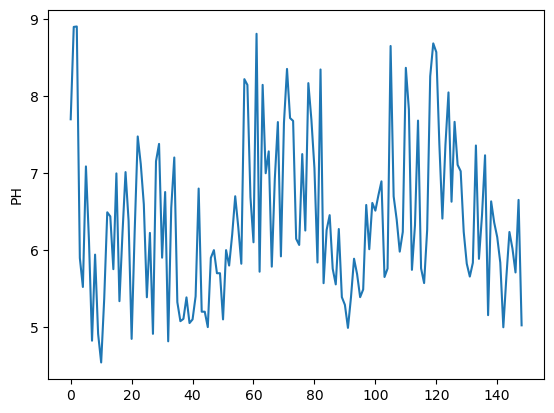

In [80]:
n = 3*24*7
sns.lineplot(data=(df[::n]),x=range(len(df[::n])),y="PH")

<Axes: ylabel='DO'>

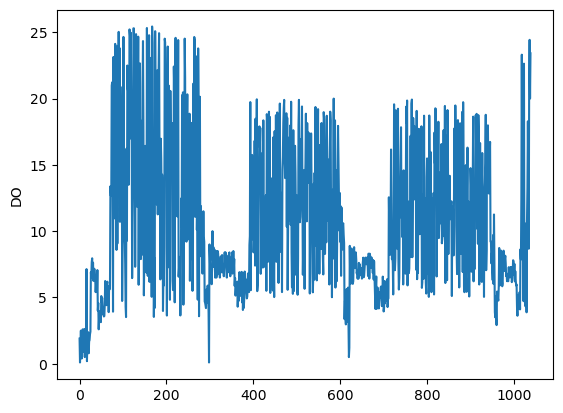

In [104]:
n = 3*24
sns.lineplot(data=(df[::n]),x=range(len(df[::n])),y="DO")

<Axes: ylabel='TURBIDITY'>

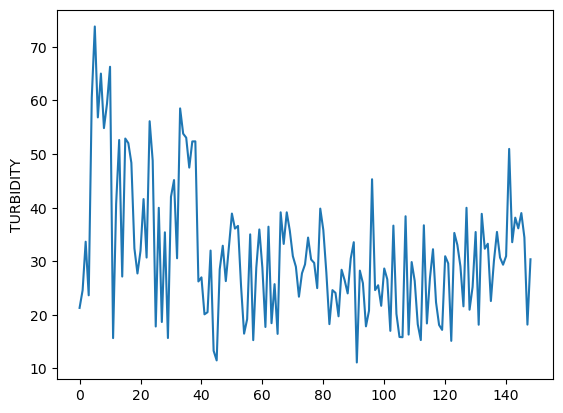

In [114]:
n = 3*24*7
sns.lineplot(data=(df[::n]),x=range(len(df[::n])),y="TURBIDITY")

In [41]:
def shift_model(df,lag):
    temp_df = df.copy()
    for i in range(1,lag+1):
        temp_df[[f"{column}_lag_{i}" for column in df.columns]] = df.shift(i)
    return temp_df.dropna()

In [140]:
df_shift.columns

Index(['PH', 'TEMP', 'DO', 'TURBIDITY', 'PH_lag_1', 'TEMP_lag_1', 'DO_lag_1',
       'TURBIDITY_lag_1', 'PH_lag_2', 'TEMP_lag_2', 'DO_lag_2',
       'TURBIDITY_lag_2', 'PH_lag_3', 'TEMP_lag_3', 'DO_lag_3',
       'TURBIDITY_lag_3'],
      dtype='object')

<Axes: >

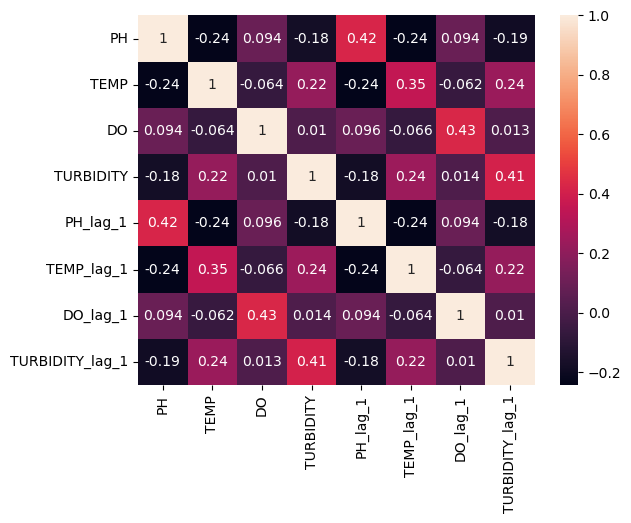

In [178]:
n = 1
df_shift = shift_model(df,n)
sns.heatmap(df_shift.corr(),annot=True)

In [195]:
df_shift.corr()

,PH,TEMP,DO,TURBIDITY,PH_lag_1,TEMP_lag_1,DO_lag_1,TURBIDITY_lag_1
PH,1.000000,-0.235923,0.093740,-0.175623,0.423450,-0.242485,0.093930,-0.185075
TEMP,-0.235923,1.000000,-0.064477,0.223188,-0.240510,0.351909,-0.061851,0.237664
DO,0.093740,-0.064477,1.000000,0.010357,0.095857,-0.065761,0.428844,0.013048
TURBIDITY,-0.175623,0.223188,0.010357,1.000000,-0.183602,0.238498,0.014411,0.411434
PH_lag_1,0.423450,-0.240510,0.095857,-0.183602,1.000000,-0.235941,0.093711,-0.175634
TEMP_lag_1,-0.242485,0.351909,-0.065761,0.238498,-0.235941,1.000000,-0.064496,0.223195
DO_lag_1,0.093930,-0.061851,0.428844,0.014411,0.093711,-0.064496,1.000000,0.010374
TURBIDITY_lag_1,-0.185075,0.237664,0.013048,0.411434,-0.175634,0.223195,0.010374,1.000000


In [170]:
for col in df.columns:
    print("-"*40)
    print(col)
    for lag in range(3*23,(3*24*7)+5):
        print("lag",lag,":",end=" ")
        print(df[col].autocorr(lag=lag))

----------------------------------------
PH
lag 69 : 0.40639897840760886
lag 70 : 0.4058121510445002
lag 71 : 0.403568387515361
lag 72 : 0.4052723020657475
lag 73 : 0.40822923370661945
lag 74 : 0.4051448753918174
lag 75 : 0.40400713455260695
lag 76 : 0.40378606969489467
lag 77 : 0.40424791873600197
lag 78 : 0.40287578367965593
lag 79 : 0.40331841962705023
lag 80 : 0.40883444339081054
lag 81 : 0.4035727837628529
lag 82 : 0.4014149146637548
lag 83 : 0.4085830852739912
lag 84 : 0.40748891641426715
lag 85 : 0.40539157755260724
lag 86 : 0.40442489801469833
lag 87 : 0.4047751499563908
lag 88 : 0.40337138561570923
lag 89 : 0.40001064622762866
lag 90 : 0.3994225346391372
lag 91 : 0.39957682109676973
lag 92 : 0.40751577834425423
lag 93 : 0.3983666498413083
lag 94 : 0.39981689443016905
lag 95 : 0.39953072698364844
lag 96 : 0.3981498959432261
lag 97 : 0.39978071872258086
lag 98 : 0.3996207703956151
lag 99 : 0.39911513455821523
lag 100 : 0.3986876985073144
lag 101 : 0.3986161737372269
lag 102 : 0.

In [78]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# 1. Load your exact zero-indexed data
data = pd.DataFrame({
    'Temperature': [27.598028, 27.217041, 27.688613, 28.213818, 27.159508],
    'Dissolved_Oxygen': [6.916388, 6.871578, 5.950694, 6.335761, 6.563543],
    'pH': [7.937212, 7.872365, 7.941378, 7.804893, 7.822742],
    'Turbidity': [3.677379, 4.110987, 3.039369, 3.611809, 3.885563]
})

# Convert to a clean numpy array for zero-indexed array manipulation
values = data.values 

# 2. Windowing function to map history to a single target
def create_windows(dataset, window_size, target_col_idx):
    X, y = [], []
    for i in range(len(dataset) - window_size):
        # Slice the window of history (e.g., indices i and i+1)
        window = dataset[i:(i + window_size), :]
        print(window)
        X.append(window.flatten())  # Flatten the 2x4 matrix into an 8-element row
        y.append(dataset[i + window_size, target_col_idx]) # The next step value
    return np.array(X), np.array(y)

# Parameters
LOOKBACK_WINDOW = 2
TARGET_INDEX = 0  # 0 corresponds to predicting 'Temperature'

# Generate features and targets
X, y = create_windows(values, LOOKBACK_WINDOW, TARGET_INDEX)


[[27.598028  6.916388  7.937212  3.677379]
 [27.217041  6.871578  7.872365  4.110987]]
[[27.217041  6.871578  7.872365  4.110987]
 [27.688613  5.950694  7.941378  3.039369]]
[[27.688613  5.950694  7.941378  3.039369]
 [28.213818  6.335761  7.804893  3.611809]]


In [76]:
X

array([[27.598028,  6.916388,  7.937212,  3.677379, 27.217041,  6.871578,
         7.872365,  4.110987],
       [27.217041,  6.871578,  7.872365,  4.110987, 27.688613,  5.950694,
         7.941378,  3.039369],
       [27.688613,  5.950694,  7.941378,  3.039369, 28.213818,  6.335761,
         7.804893,  3.611809]])

In [ ]:
n = 3*24*7*4
for i in df.columns:
    stl = STL(df[i],period=n)
    result = stl.fit()
    result.plot()
    plt.title(i)
    plt.show()

In [7]:
df= pd.read_csv("./Dataset-demo/Realtime-env2.csv")

In [21]:
df["label"].value_counts()

label
1    54746
0    20012
Name: count, dtype: int64

In [109]:
df_water = pd.read_excel("./Wait_confirm_dataset/Water Quality Dataset.xlsx")

In [111]:
df_water = df_water[["Temp","DO(mg/L)","pH`","Turbidity (cm)","Water Quality"]]

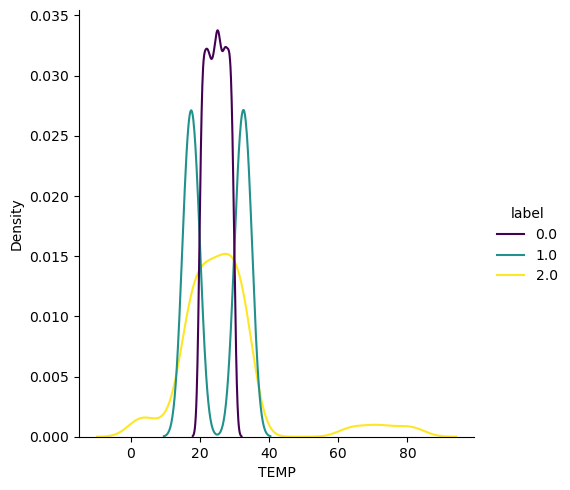

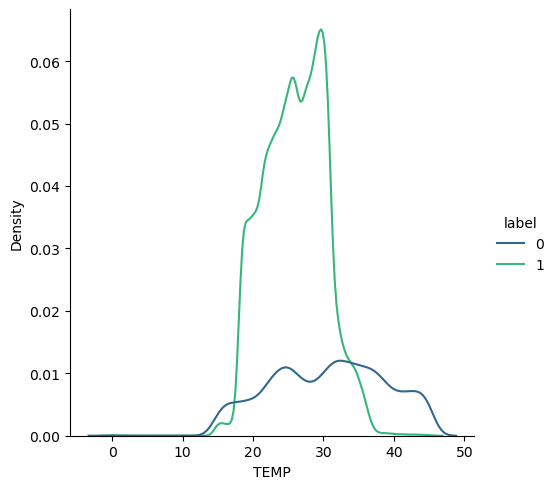

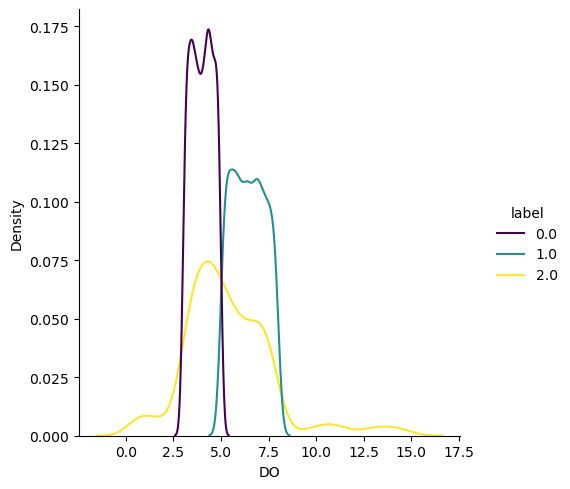

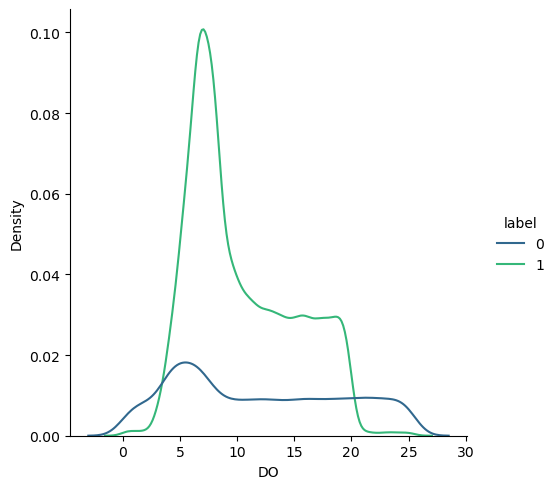

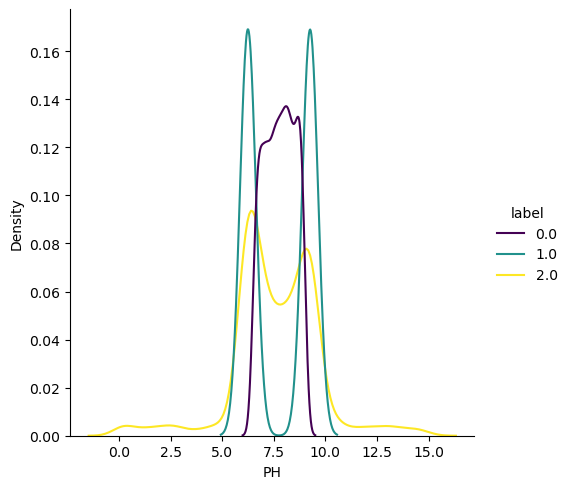

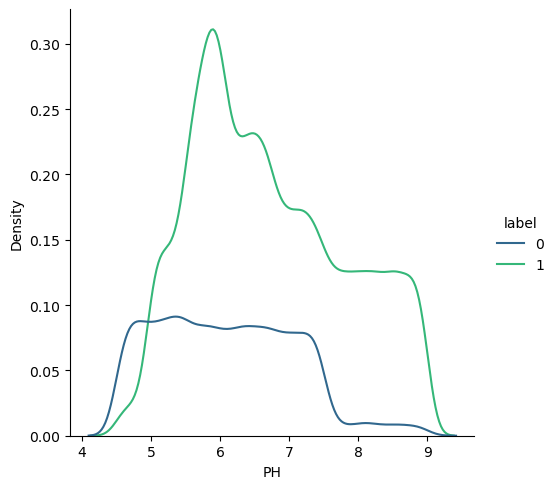

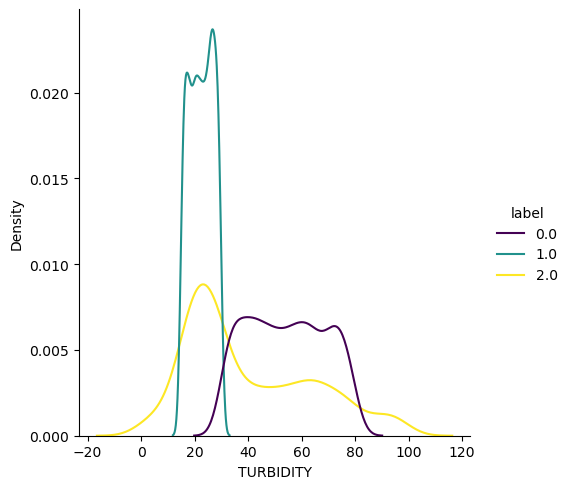

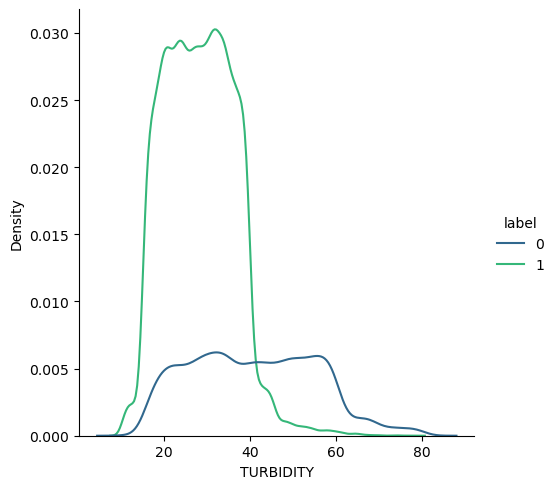

/tmp/ipykernel_4170/4097477377.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(df_water,x=i,hue="label",palette="viridis",kind="kde")
/tmp/ipykernel_4170/4097477377.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(df_fish,x=i,hue="label",palette="viridis",kind="kde")


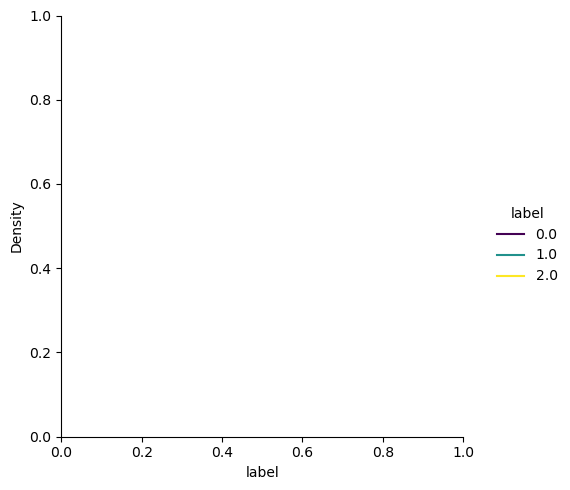

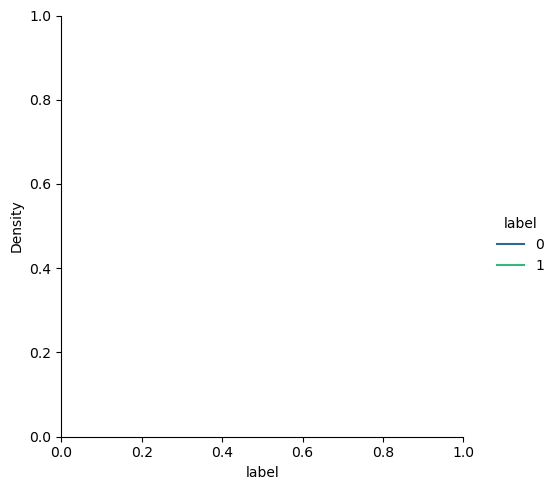

In [125]:
for i in df_water.columns:
    sns.displot(df_water,x=i,hue="label",palette="viridis",kind="kde")
    sns.displot(df_fish,x=i,hue="label",palette="viridis",kind="kde")
    plt.show()

In [121]:
df_fish.columns

Index(['PH', 'TEMP', 'DO', 'TURBIDITY', 'label'], dtype='object')

In [123]:
df_water.columns

Index(['TEMP', 'DO', 'PH', 'TURBIDITY', 'label'], dtype='object')

In [113]:
columns = df_water.columns
df_water[["TEMP","DO","PH","TURBIDITY","label"]] = df_water.values
df_water.drop(columns=columns,inplace=True)

In [107]:
df_water.head()

,Temp,DO(mg/L),pH`,Turbidity (cm),Water Quality,TEMP,DO,PH,TURBIDITY,label
0,67.448725,0.208153,4.751657,10.127148,2,67.448725,0.208153,4.751657,10.127148,2.0
1,64.626666,11.434463,3.085154,94.015595,2,64.626666,11.434463,3.085154,94.015595,2.0
2,65.121842,12.430865,9.648515,90.653462,2,65.121842,12.430865,9.648515,90.653462,2.0
3,1.640334,10.963529,4.819988,0.066344,2,1.640334,10.963529,4.819988,0.066344,2.0
4,64.863434,1.361736,10.244034,2.119173,2,64.863434,1.361736,10.244034,2.119173,2.0
